In [88]:
# ======= Variables =========

# Fill in the variables below and run cell first
# Note: Use forward slashes / instead of backslashes \ in file paths

DATASET_DIR = "../dataset"
OUTPUT_DIR = f"{DATASET_DIR}/original_sheets"

MODEL_TABLE_FILENAME = "model_table.csv"
DIAGNOSIS_DATASET_FILENAME = "diagnosis_dataset.csv"
OUTPUT_MODEL_TABLE_FILENAME = "model_table_feature_engineered.csv"

TRAINING_SET_CSV_FILE_PATH = f"{DATASET_DIR}/training_set.csv"
TEST_SET_CSV_FILE_PATH = f"{DATASET_DIR}/test_set.csv"
TEST_SET_SIZE = 0.1  # fraction of the dataset to be used as test set

MODEL_FOLDER_PATH = "../models"

RANDOM_SEED = 123

In [89]:
# ========= Libraries =========

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [90]:
# ========= Create Training and Test sets =========

# Load dataset into a pandas DataFrame
df = pd.read_csv(f"{DATASET_DIR}/{OUTPUT_MODEL_TABLE_FILENAME}")

# ============== Preprocessing steps ==============
df = df[df["HIGH_RISK"] == 1]  # Keep only the high-risk patients
df = df.drop(
    columns=["HIGH_RISK", "PATIENT_ID", "DISEASEX_DT"]
)  # Drop columns that will not be used as features for training the model

# One-hot encode categorical features using the training schema enums
import importlib
import sys
from pathlib import Path

from sklearn.model_selection import train_test_split

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import ml_antiviral_diagnosis.feature_engineering as feature_engineering_module

importlib.reload(feature_engineering_module)

categorical_columns = [
    column
    for column in feature_engineering_module.MODEL_TABLE_CATEGORICAL_COLUMNS
    if column in df.columns
]

for column in categorical_columns:
    enum_type = feature_engineering_module.MODEL_TABLE_CATEGORICAL_ENUMS[column]
    allowed_values = [member.value for member in enum_type]
    unexpected_values = sorted(set(df[column].dropna().astype(str)) - set(allowed_values))
    if unexpected_values:
        raise ValueError(f"Unexpected values for {column}: {unexpected_values}")
    df[column] = pd.Categorical(df[column], categories=allowed_values)

df = pd.get_dummies(df, columns=categorical_columns, dtype=int)
print(f"Encoded dataset: rows={df.shape[0]}, columns={df.shape[1]}")

# Separate a stratified Test set and keep it aside
dfTraining, dfTest = train_test_split(
    df,
    test_size=TEST_SET_SIZE,
    random_state=RANDOM_SEED,
    stratify=df["TARGET"],
)

print(
    f"Training target rate: {dfTraining['TARGET'].mean():.3f} "
    f"({int(dfTraining['TARGET'].sum())}/{len(dfTraining)})"
)
print(
    f"Test target rate: {dfTest['TARGET'].mean():.3f} "
    f"({int(dfTest['TARGET'].sum())}/{len(dfTest)})"
)

# Save the Training and Test sets to CSV files
dfTraining.to_csv(TRAINING_SET_CSV_FILE_PATH, index=False)
dfTest.to_csv(TEST_SET_CSV_FILE_PATH, index=False)

Encoded dataset: rows=2507, columns=171
Training target rate: 0.191 (431/2256)
Test target rate: 0.191 (48/251)


In [91]:
# ========= Load Training and Test sets =========

# Load the Training set into a pandas dataframe
dfTraining = pd.read_csv(TRAINING_SET_CSV_FILE_PATH)

# Load the Test set into a pandas dataframe
dfTest = pd.read_csv(TEST_SET_CSV_FILE_PATH)

In [92]:
# ========= Prepare Training and Test sets as Arrays =========

TARGET_COLUMN = "TARGET"

X_train = dfTraining.drop(columns=[TARGET_COLUMN]).to_numpy()
y_train = dfTraining[TARGET_COLUMN].to_numpy()

X_test = dfTest.drop(columns=[TARGET_COLUMN]).to_numpy()
y_test = dfTest[TARGET_COLUMN].to_numpy()

In [97]:
# ========= Functions for classification metrics and plots =========

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


def compute_classification_metrics(y_true, y_pred, y_score):
    """Compute classification metrics for a binary target."""
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, y_score),
        "PR AUC": average_precision_score(y_true, y_score),
    }


def print_metrics(metrics, label=""):
    """Nicely print out a classification metrics dictionary."""
    prefix = f"{label} " if label else ""
    print(
        f"{prefix}Accuracy: {metrics['Accuracy']:.3f}, "
        f"Balanced Accuracy: {metrics['Balanced Accuracy']:.3f}, "
        f"Precision: {metrics['Precision']:.3f}, "
        f"Recall: {metrics['Recall']:.3f}, "
        f"F1: {metrics['F1']:.3f}, "
        f"ROC AUC: {metrics['ROC AUC']:.3f}, "
        f"PR AUC: {metrics['PR AUC']:.3f}"
    )


def plot_probability_by_class(y_true, y_score, set_name=""):
    """Plot predicted probabilities grouped by actual class."""
    plt.figure(figsize=(7, 4))
    plt.hist(y_score[y_true == 0], bins=20, alpha=0.7, label="Actual 0")
    plt.hist(y_score[y_true == 1], bins=20, alpha=0.7, label="Actual 1")
    plt.xlabel(f"Predicted probability of {TARGET_COLUMN}=1")
    plt.ylabel("Count")
    title = (
        f"Predicted probability by actual class ({set_name})"
        if set_name
        else "Predicted probability by actual class"
    )
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_actual_vs_predicted(y_true, y_score, set_name=""):
    """Scatter plot of actual class versus predicted probability."""
    rng = np.random.default_rng(RANDOM_SEED)
    x_jittered = y_true + rng.uniform(-0.03, 0.03, size=len(y_true))
    plt.figure(figsize=(6, 6))
    plt.scatter(x_jittered, y_score, alpha=0.45, s=16)
    plt.axhline(0.5, color="r", linestyle="--", linewidth=1, label="0.5 threshold")
    plt.xticks([0, 1], ["Actual 0", "Actual 1"])
    plt.xlim(-0.15, 1.15)
    plt.ylim(-0.02, 1.02)
    plt.xlabel(f"Actual {TARGET_COLUMN}")
    plt.ylabel(f"Predicted probability of {TARGET_COLUMN}=1")
    title = f"Actual vs Predicted ({set_name})" if set_name else "Actual vs Predicted"
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_confusion(y_true, y_pred, set_name=""):
    """Plot a confusion matrix for the predictions."""
    disp = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred))
    disp.plot(cmap="Blues", colorbar=False)
    title = f"Confusion Matrix ({set_name})" if set_name else "Confusion Matrix"
    plt.title(title)
    plt.tight_layout()
    plt.show()

TRAIN Accuracy: 0.662, Balanced Accuracy: 0.689, Precision: 0.328, Recall: 0.733, F1: 0.453, ROC AUC: 0.762, PR AUC: 0.452
TEST Accuracy: 0.657, Balanced Accuracy: 0.677, Precision: 0.321, Recall: 0.708, F1: 0.442, ROC AUC: 0.737, PR AUC: 0.309


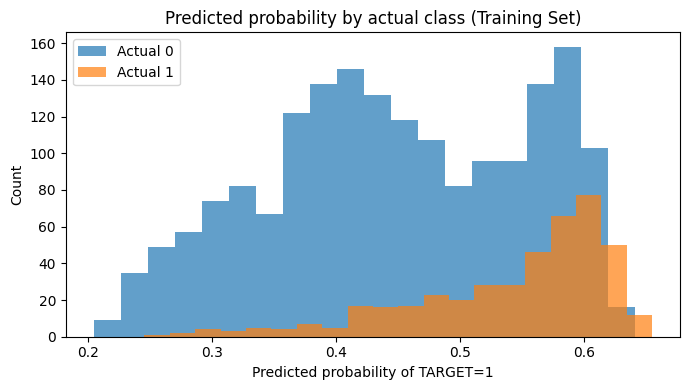

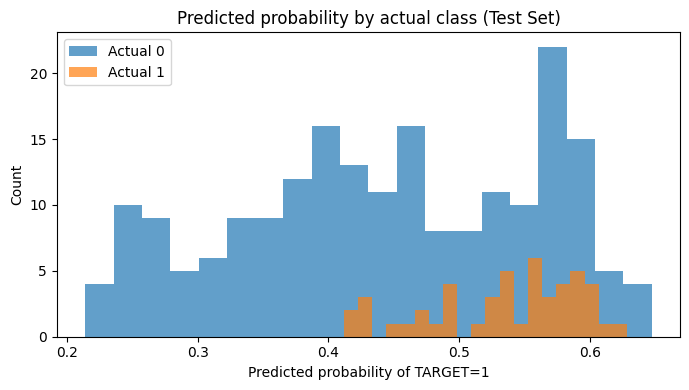

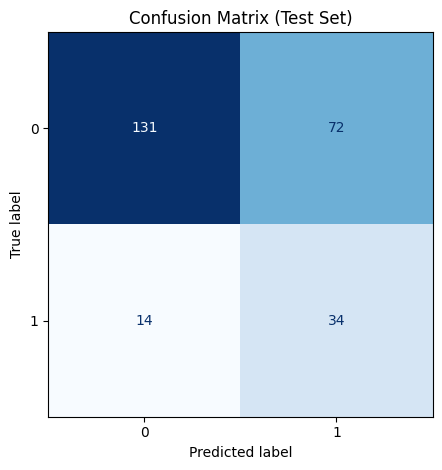

In [ ]:
# ========= Train the Random Forest classifier =========

from sklearn.ensemble import RandomForestClassifier

N_TREES = 300  # Number of trees in the forest

# --- Train the model ---
model = RandomForestClassifier(
    n_estimators=N_TREES,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
model.fit(X_train, y_train)

# --- Predict probabilities and labels ---
y_train_score = model.predict_proba(X_train)[:, 1]
y_test_score = model.predict_proba(X_test)[:, 1]
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# --- Compute & print metrics ---
train_metrics = compute_classification_metrics(y_train, y_train_pred, y_train_score)
test_metrics = compute_classification_metrics(y_test, y_test_pred, y_test_score)

print_metrics(train_metrics, label="TRAIN")
print_metrics(test_metrics, label="TEST")

# --- Plot ---
plot_actual_vs_predicted(y_train, y_train_score, set_name="Training Set")
plot_actual_vs_predicted(y_test, y_test_score, set_name="Test Set")
plot_probability_by_class(y_train, y_train_score, set_name="Training Set")
plot_probability_by_class(y_test, y_test_score, set_name="Test Set")
plot_confusion(y_test, y_test_pred, set_name="Test Set")

In [95]:
# ========= Save model =========
import joblib


def getCurrentTimestampString():
    """Get current timestamp in the format YYYYMMDD-HHMMSS."""
    from datetime import datetime

    return datetime.now().strftime("%Y%m%d-%H%M%S")


joblib.dump(
    model,
    f"{MODEL_FOLDER_PATH}/{getCurrentTimestampString()}_random_forest_classifier.joblib",
    compress=3,
)
print("Model saved successfully!")

Model saved successfully!


In [ ]:
# ========= Load model =========
import joblib

MODEL_FILENAME = "20260321-004014_random_forest_classifier.joblib"  # Update this to the actual filename of the model you want to load

# Update the path manually
model = joblib.load(f"{MODEL_FOLDER_PATH}/{MODEL_FILENAME}")
print("Model loaded successfully!")

Model loaded successfully!


TRAIN Accuracy: 0.662, Balanced Accuracy: 0.689, Precision: 0.328, Recall: 0.733, F1: 0.453, ROC AUC: 0.762, PR AUC: 0.452
TEST Accuracy: 0.657, Balanced Accuracy: 0.677, Precision: 0.321, Recall: 0.708, F1: 0.442, ROC AUC: 0.737, PR AUC: 0.309


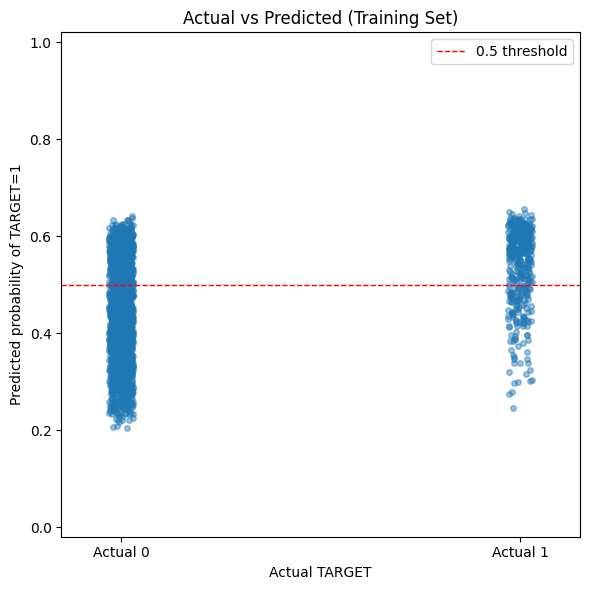

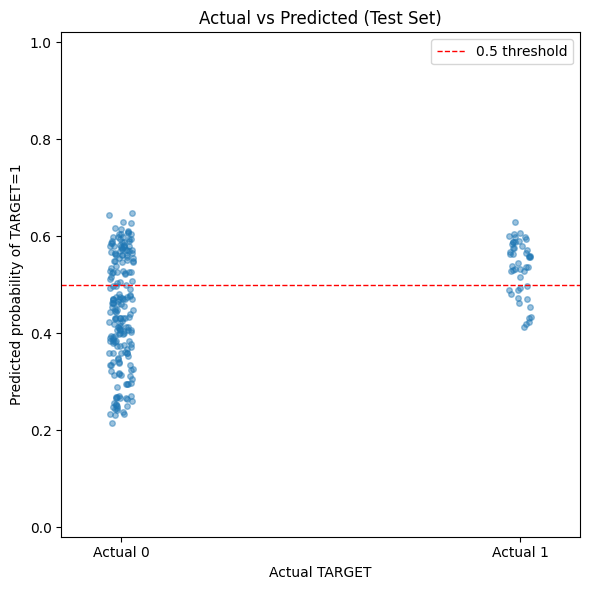

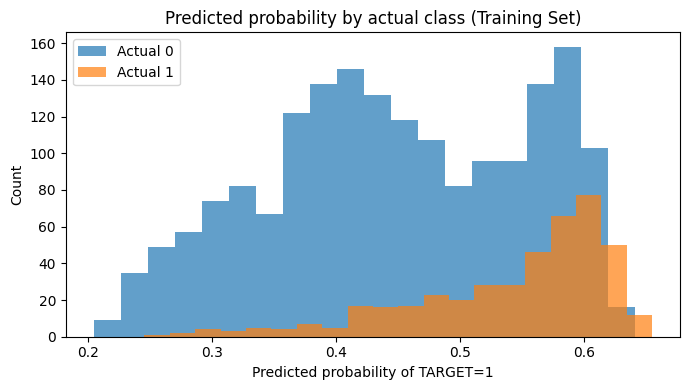

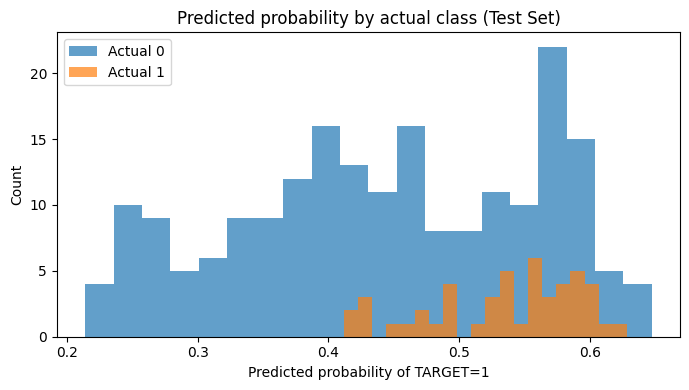

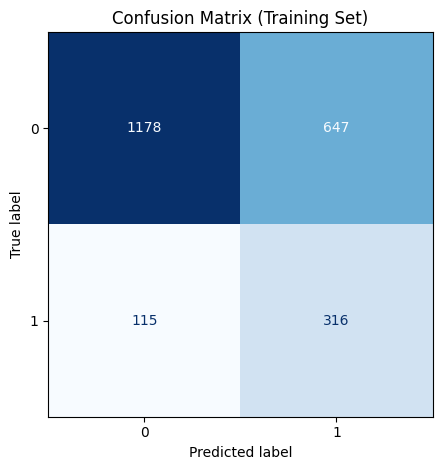

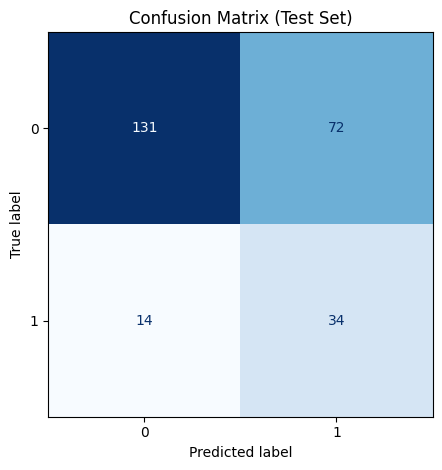

In [99]:
# --- Predict probabilities and labels ---
y_train_score = model.predict_proba(X_train)[:, 1]
y_test_score = model.predict_proba(X_test)[:, 1]
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# --- Compute & print metrics ---
train_metrics = compute_classification_metrics(y_train, y_train_pred, y_train_score)
test_metrics = compute_classification_metrics(y_test, y_test_pred, y_test_score)

print_metrics(train_metrics, label="TRAIN")
print_metrics(test_metrics, label="TEST")

# --- Plot ---
plot_actual_vs_predicted(y_train, y_train_score, set_name="Training Set")
plot_actual_vs_predicted(y_test, y_test_score, set_name="Test Set")
plot_probability_by_class(y_train, y_train_score, set_name="Training Set")
plot_probability_by_class(y_test, y_test_score, set_name="Test Set")
plot_confusion(y_train, y_train_pred, set_name="Training Set")
plot_confusion(y_test, y_test_pred, set_name="Test Set")